# 07 — Comparaison globale des méthodes

Notebook orchestrateur qui ajuste **toutes les méthodes implémentées à
ce stade** sur le même champ + capteurs et sauvegarde les métriques.

Méthodes incluses (13) :
- ``BaselineConstant`` — borne inférieure.
- ``OrdinaryKrigingIndicator``, ``UniversalKrigingEdge``,
  ``IndicatorKrigingThreshold`` — variantes géostatistiques.
- ``MaternGPRegressor``, ``MaternGPClassifier`` — processus gaussiens.
- ``SpatialRandomForest`` — RF géo-aware.
- ``SADIE`` — SADIE simplifié + IDW.
- ``IsingMRF`` — Markov Random Field V1 NumPy.
- ``MaternGLMM`` — GLMM bayésien Matérn (PyMC).
- ``CARModel`` / ``BYMModel`` — Conditional Autoregressive (PyMC).
- ``SARLagModel`` — Simultaneous Autoregressive (spreg).

Deux scénarios sont étudiés :
1. **Scénario par défaut** : 20 capteurs uniformes, K=50, seed 2024.
2. **Robustesse au schéma de placement** : on répète sur 5 schémas
   distincts.

Les méthodes bayésiennes utilisent peu de draws/tune (200+200, 2 chaînes)
pour rester rapides. Le notebook complet prend ~30 minutes à exécuter.

Les résultats sont sauvés dans ``outputs/results/07_comparison.csv``.

In [1]:
import logging
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from aphid_spatial.evaluation.metrics import evaluate_all
from aphid_spatial.methods.exploration import BaselineConstant
from aphid_spatial.methods.geostatistics import (
    IndicatorKrigingThreshold,
    OrdinaryKrigingIndicator,
    UniversalKrigingEdge,
)
from aphid_spatial.methods.gp import MaternGPClassifier, MaternGPRegressor
from aphid_spatial.methods.hierarchical import MaternGLMM
from aphid_spatial.methods.lattice import (
    BYMModel,
    CARModel,
    IsingMRF,
    SARLagModel,
)
from aphid_spatial.methods.ml import SpatialRandomForest
from aphid_spatial.methods.sadie import SADIE
from aphid_spatial.simulation import (
    Field,
    FieldConfig,
    SensorConfig,
    place_sensors,
    simulate_field,
)
from aphid_spatial.visualization.maps import plot_field, plot_prediction

logging.basicConfig(level=logging.WARNING, format="%(name)s | %(message)s")
FIG_DIR = Path("../outputs/figures")
RES_DIR = Path("../outputs/results")
FIG_DIR.mkdir(parents=True, exist_ok=True)
RES_DIR.mkdir(parents=True, exist_ok=True)

In [2]:
def make_methods():
    """Liste fraîche d'instances ; les classes contenant un état doivent être
    recréées à chaque schéma pour éviter la fuite d'information.

    Méthodes bayésiennes : draws/tune réduits (200+200, 2 chaînes) pour
    garder le notebook exécutable en ~30 min sur 5 placements × 13 méthodes.
    """
    return [
        BaselineConstant(),
        OrdinaryKrigingIndicator(),
        UniversalKrigingEdge(),
        IndicatorKrigingThreshold(threshold=0.5),
        MaternGPRegressor(length_scale=15.0),
        MaternGPClassifier(threshold=0.5),
        SpatialRandomForest(n_estimators=200, max_depth=8),
        SADIE(n_permutations=99),
        IsingMRF(neighborhood="queen", n_burn=100, n_samples=200, seed=0),
        SARLagModel(n_neighbors=4),
        MaternGLMM(n_draws=200, n_tune=200, chains=2, n_predict_samples=50, seed=0),
        CARModel(n_neighbors=4, n_draws=200, n_tune=200, chains=2, n_predict_samples=50, seed=0),
        BYMModel(n_neighbors=4, n_draws=200, n_tune=200, chains=2, n_predict_samples=50, seed=0),
    ]

data_path = Path("../data/simulated/field_default.npz")
field = Field.load(data_path) if data_path.exists() else simulate_field(FieldConfig(seed=42))
print(f"Champ : {field.coords.shape[0]} cellules ; prévalence vraie : {field.presence.mean():.3f}")

Champ : 100000 cellules ; prévalence vraie : 0.239


## Scénario 1 : capteurs uniformes (référence)

In [3]:
readings = place_sensors(
    field, SensorConfig(n_sensors=20, placement="uniform", n_observations=50, seed=2024)
)

rows = []
preds = {}
for m in make_methods():
    try:
        m.fit(readings, field)
        p = m.predict_proba(field.coords)
        preds[m.name] = p
        metrics = evaluate_all(field.presence, p, p_true=field.prob)
        rows.append({"method": m.name, "placement": "uniform", **metrics})
    except Exception as exc:  # noqa: BLE001
        print(f"  ! {m.name} a échoué : {type(exc).__name__}: {exc}")

df1 = pd.DataFrame(rows).sort_values("auc_roc", ascending=False).reset_index(drop=True)
df1

GM_Lag


Initializing NUTS using jitter+adapt_diag...


pymc.sampling.mcmc | Initializing NUTS using jitter+adapt_diag...


Multiprocess sampling (2 chains in 2 jobs)


pymc.sampling.mcmc | Multiprocess sampling (2 chains in 2 jobs)


...

The rhat statistic is larger than 1.01 for some parameters. This indicates problems during sampling. See https://arxiv.org/abs/1903.08008 for details


pymc.stats.convergence | The rhat statistic is larger than 1.01 for some parameters. This indicates problems during sampling. See https://arxiv.org/abs/1903.08008 for details


The effective sample size per chain is smaller than 100 for some parameters.  A higher number is needed for reliable rhat and ess computation. See https://arxiv.org/abs/1903.08008 for details


pymc.stats.convergence | The effective sample size per chain is smaller than 100 for some parameters.  A higher number is needed for reliable rhat and ess computation. See https://arxiv.org/abs/1903.08008 for details


,method,placement,auc_roc,auc_pr,brier,log_loss,prevalence_true,prevalence_pred,mae_prob,rmse_prob
0,sar_lag_spreg,uniform,0.688038,0.381575,0.176831,0.536010,0.23929,0.236233,0.125866,0.165969
1,bym_pymc,uniform,0.685411,0.394615,0.168812,0.515004,0.23929,0.240952,0.102115,0.139598
2,universal_kriging_edge,uniform,0.681079,0.382612,0.169144,0.515432,0.23929,0.246609,0.100880,0.140343
3,sadie_simplified,uniform,0.679738,0.397125,0.168672,0.515378,0.23929,0.256711,0.103875,0.138807
4,car_pymc,uniform,0.675385,0.396324,0.169391,0.517171,0.23929,0.247025,0.105244,0.141487
5,matern_glmm_pymc,uniform,0.674532,0.372457,0.170113,0.517515,0.23929,0.242591,0.102402,0.143840
6,ordinary_kriging_indicator,uniform,0.672099,0.379204,0.169846,0.517349,0.23929,0.255963,0.105062,0.142466
7,gp_matern_regressor,uniform,0.658255,0.363177,0.171958,0.522665,0.23929,0.248715,0.111977,0.149865
8,gp_matern_classifier,uniform,0.635911,0.355257,0.177828,0.537778,0.23929,0.263062,0.127145,0.168536
9,indicator_kriging_threshold,uniform,0.630265,0.365992,0.197454,0.739498,0.23929,0.121413,0.167001,0.219432


## Scénario 2 : robustesse au schéma de placement

On répète l'évaluation sur les 5 schémas, avec le même seed. Les méthodes
lentes (`IsingMRF`, GP) sont conservées : ce notebook prend ~5 minutes à
exécuter.

In [4]:
schemes = ["uniform", "grid", "stratified", "edge_biased", "poisson_disk"]
rows_all = []
for s in schemes:
    print(f"=== Placement : {s} ===")
    r_s = place_sensors(
        field, SensorConfig(n_sensors=20, placement=s, n_observations=50, seed=2024)
    )
    for m in make_methods():
        try:
            m.fit(r_s, field)
            p = m.predict_proba(field.coords)
            metrics = evaluate_all(field.presence, p, p_true=field.prob)
            rows_all.append({"method": m.name, "placement": s, **metrics})
        except Exception as exc:  # noqa: BLE001
            print(f"  ! {m.name} ({s}) a échoué : {type(exc).__name__}: {exc}")

df_all = pd.DataFrame(rows_all)
df_all.to_csv(RES_DIR / "07_comparison.csv", index=False)
print(f"\nCSV sauvegardé : {RES_DIR / '07_comparison.csv'}")
df_all.head(15)

=== Placement : uniform ===


GM_Lag


Initializing NUTS using jitter+adapt_diag...


pymc.sampling.mcmc | Initializing NUTS using jitter+adapt_diag...


Multiprocess sampling (2 chains in 2 jobs)


...

pymc.stats.convergence | The rhat statistic is larger than 1.01 for some parameters. This indicates problems during sampling. See https://arxiv.org/abs/1903.08008 for details


The effective sample size per chain is smaller than 100 for some parameters.  A higher number is needed for reliable rhat and ess computation. See https://arxiv.org/abs/1903.08008 for details


pymc.stats.convergence | The effective sample size per chain is smaller than 100 for some parameters.  A higher number is needed for reliable rhat and ess computation. See https://arxiv.org/abs/1903.08008 for details



CSV sauvegardé : ..\outputs\results\07_comparison.csv


,method,placement,auc_roc,auc_pr,brier,log_loss,prevalence_true,prevalence_pred,mae_prob,rmse_prob
0,baseline_constant,uniform,0.500000,0.239290,0.182038,0.550280,0.23929,0.242000,0.141080,0.180932
1,ordinary_kriging_indicator,uniform,0.672099,0.379204,0.169846,0.517349,0.23929,0.255963,0.105062,0.142466
2,universal_kriging_edge,uniform,0.681079,0.382612,0.169144,0.515432,0.23929,0.246609,0.100880,0.140343
3,indicator_kriging_threshold,uniform,0.630265,0.365992,0.197454,0.739498,0.23929,0.121413,0.167001,0.219432
4,gp_matern_regressor,uniform,0.658255,0.363177,0.171958,0.522665,0.23929,0.248715,0.111977,0.149865
5,gp_matern_classifier,uniform,0.635911,0.355257,0.177828,0.537778,0.23929,0.263062,0.127145,0.168536
6,spatial_random_forest,uniform,0.622308,0.349431,0.174703,0.531199,0.23929,0.233919,0.115181,0.159953
7,sadie_simplified,uniform,0.679738,0.397125,0.168672,0.515378,0.23929,0.256711,0.103875,0.138807
8,ising_mrf_v1,uniform,0.501456,0.240057,0.182903,0.553153,0.23929,0.242310,0.142724,0.183272
9,sar_lag_spreg,uniform,0.688038,0.381575,0.176831,0.536010,0.23929,0.236233,0.125866,0.165969


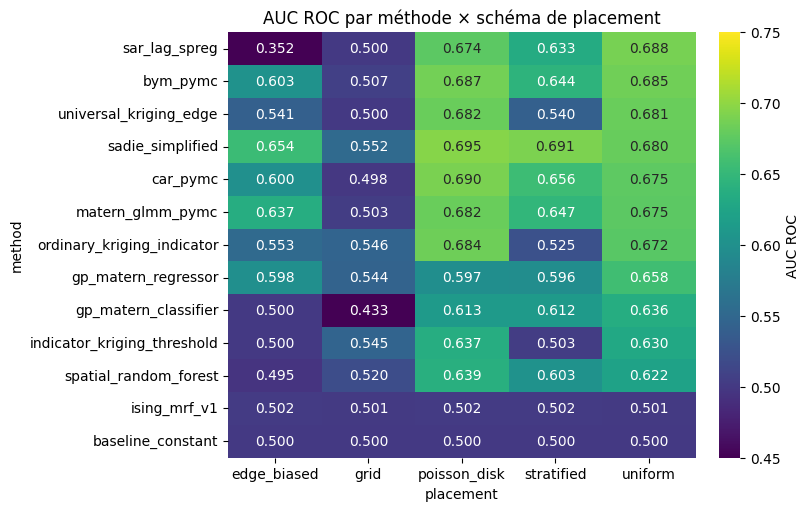

In [5]:
# Heatmap AUC ROC par méthode × placement
pivot = df_all.pivot(index="method", columns="placement", values="auc_roc")
pivot = pivot.loc[df1["method"]]  # ordonner par AUC du scénario 1
fig, ax = plt.subplots(figsize=(8, 5), constrained_layout=True)
sns.heatmap(
    pivot, annot=True, fmt=".3f", cmap="viridis", vmin=0.45, vmax=0.75,
    cbar_kws={"label": "AUC ROC"}, ax=ax,
)
ax.set_title("AUC ROC par méthode × schéma de placement")
fig.savefig(FIG_DIR / "07_comparison_heatmap.png", dpi=150)
plt.show()

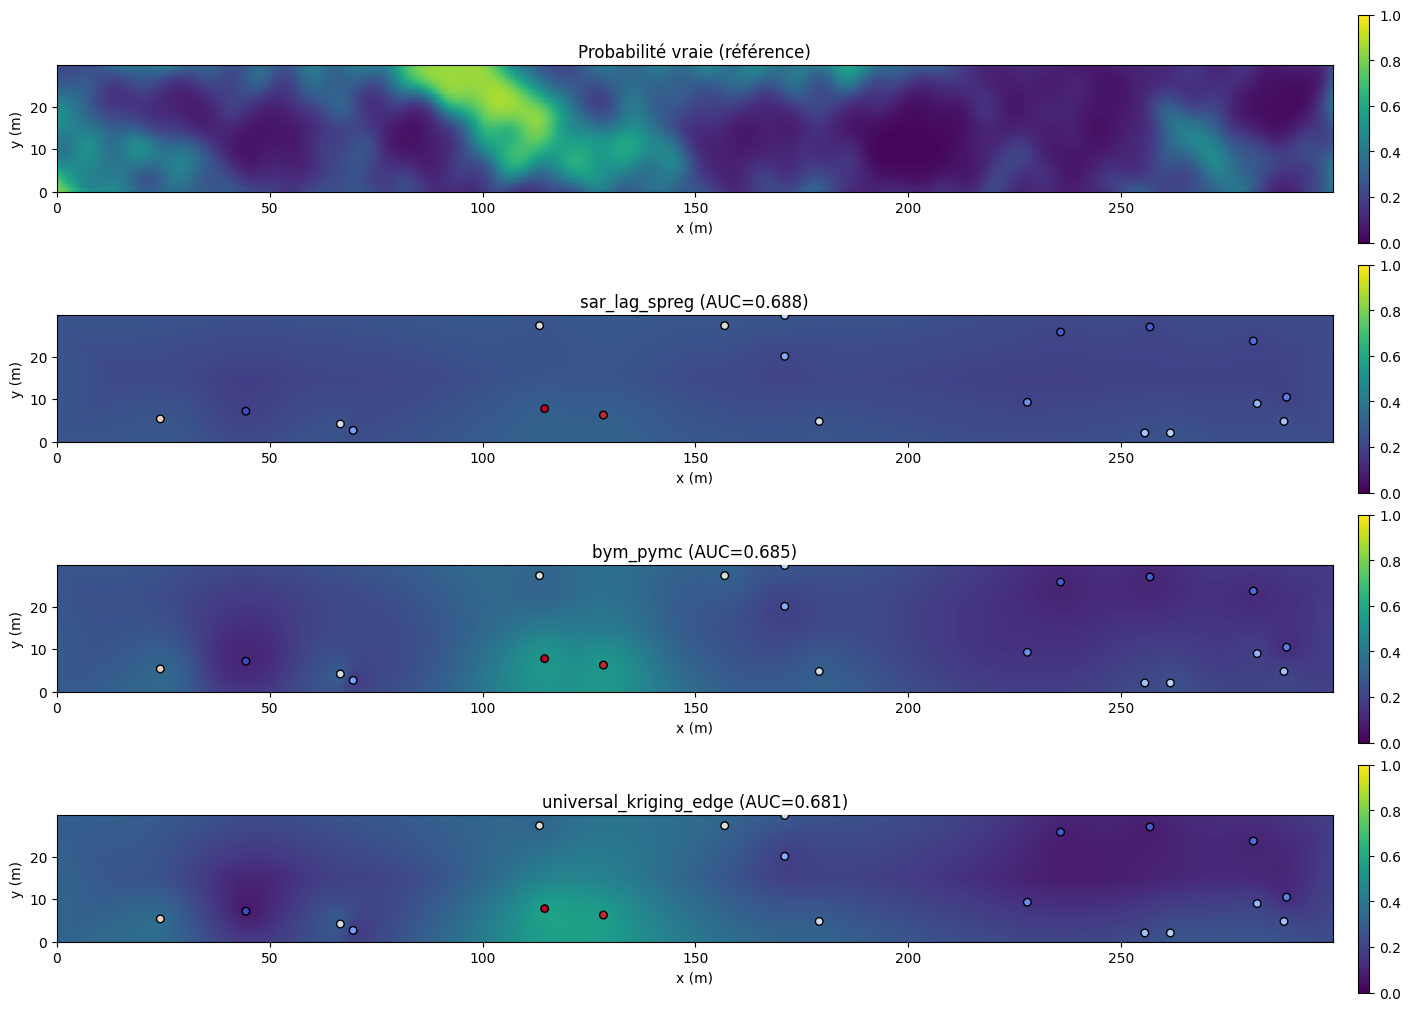

In [6]:
# Cartes des 3 meilleures méthodes (scénario uniforme)
top3 = df1.head(3)["method"].tolist()
fig, axes = plt.subplots(len(top3) + 1, 1, figsize=(14, 2.5 * (len(top3) + 1)), constrained_layout=True)
plot_field(field, "prob", ax=axes[0], title="Probabilité vraie (référence)")
for ax, name in zip(axes[1:], top3, strict=True):
    auc = df1.set_index("method").loc[name, "auc_roc"]
    plot_prediction(preds[name], field, ax=ax, readings=readings, title=f"{name} (AUC={auc:.3f})")
fig.savefig(FIG_DIR / "07_comparison_top3.png", dpi=150)
plt.show()

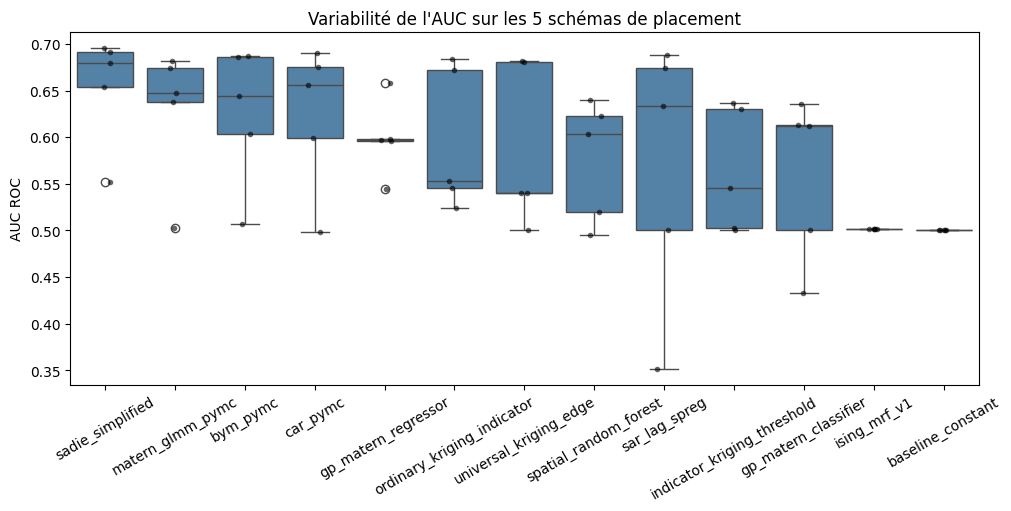

In [7]:
# Box-plot des AUC par méthode (5 placements = 5 valeurs par méthode)
method_order = df_all.groupby("method")["auc_roc"].mean().sort_values(ascending=False).index.tolist()
fig, ax = plt.subplots(figsize=(10, 5), constrained_layout=True)
sns.boxplot(
    data=df_all, x="method", y="auc_roc", order=method_order, ax=ax,
    color="steelblue",
)
sns.stripplot(
    data=df_all, x="method", y="auc_roc", order=method_order, ax=ax,
    color="black", alpha=0.6, size=4,
)
ax.set_xlabel("")
ax.set_ylabel("AUC ROC")
ax.set_title("Variabilité de l'AUC sur les 5 schémas de placement")
ax.tick_params(axis="x", rotation=30)
fig.savefig(FIG_DIR / "07_comparison_boxplot.png", dpi=150)
plt.show()